In [2]:
names = open('names.txt', 'r').read().splitlines()
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
vocab = sorted(list(set(''.join(names))))
vocab.append('<S>')
token_to_index = {c : i for i, c in enumerate(vocab)}
index_to_token = {i : c for c, i in token_to_index.items()}

print(len(vocab))

27


In [4]:
X, Y = [], []
for item in names[:2]:
    context = [token_to_index['<S>']] * 5
    tokens = list(item) + ['<S>']
    for token in tokens:
        X.append(context)
        Y.append(token_to_index[token])
        context = context[1:] + [token_to_index[token]]
    
    print(f'{X=} {Y=}')
X

X=[[26, 26, 26, 26, 26], [26, 26, 26, 26, 4], [26, 26, 26, 4, 12], [26, 26, 4, 12, 12], [26, 4, 12, 12, 0]] Y=[4, 12, 12, 0, 26]
X=[[26, 26, 26, 26, 26], [26, 26, 26, 26, 4], [26, 26, 26, 4, 12], [26, 26, 4, 12, 12], [26, 4, 12, 12, 0], [26, 26, 26, 26, 26], [26, 26, 26, 26, 14], [26, 26, 26, 14, 11], [26, 26, 14, 11, 8], [26, 14, 11, 8, 21], [14, 11, 8, 21, 8], [11, 8, 21, 8, 0]] Y=[4, 12, 12, 0, 26, 14, 11, 8, 21, 8, 0, 26]


[[26, 26, 26, 26, 26],
 [26, 26, 26, 26, 4],
 [26, 26, 26, 4, 12],
 [26, 26, 4, 12, 12],
 [26, 4, 12, 12, 0],
 [26, 26, 26, 26, 26],
 [26, 26, 26, 26, 14],
 [26, 26, 26, 14, 11],
 [26, 26, 14, 11, 8],
 [26, 14, 11, 8, 21],
 [14, 11, 8, 21, 8],
 [11, 8, 21, 8, 0]]

In [86]:
vocab_size = len(vocab)
h_size = 100
emb_size = 2
context_size = 3

### Build the dataset
* Our dataset consists of x, y pairs where x is a (n - 1)-token context, and y is a token

In [ ]:
import torch

def dataset_builder(data, context_size):
    X, Y = [], []
    
    for item in data:
        context = [token_to_index['<S>']] * context_size
        tokens = list(item) + ['<S>']
        
        for token in tokens:
            X.append(context)
            Y.append(token_to_index[token])
            context = context[1:] + [Y[-1]]
    
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(123)
random.shuffle(names)

n1 = int(0.8 * len(names))
n2 = int(0.9 * len(names))
         
xtr, ytr = dataset_builder(names[:n1], context_size)
X_dev, Y_dev = dataset_builder(names[n1:n2], context_size)
X_test, Y_test = dataset_builder(names[n2:], context_size)

xtr.shape, ytr.shape

(torch.Size([182465, 3]), torch.Size([182465]))

### Manually defining the model

In [140]:
g = torch.Generator().manual_seed(10000)

# Defining the look-up table
C = torch.randn((vocab_size, emb_size), generator=g)
print(f'{C.shape = }')

# Defining the embeddings
emb = C[xtr]
print(f'{emb.shape = }')

# Defining the parameters of layer one
W1 = torch.randn((context_size * emb_size, h_size), generator=g)
b1 = torch.randn((h_size), generator=g)

# Defining the first layer
h = torch.tanh((emb.view(-1, context_size * emb_size).matmul(W1)) + b1)
print(f'{h.shape = }')

# Defining the parameters of layer two
W2 = torch.randn((h_size, vocab_size), generator=g)
b2 = torch.randn((vocab_size), generator=g)

# Defining the second layer
logits = h.matmul(W2) + b2
print(f'{logits.shape = }')
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
print(f'{probs.shape = }')

# Defining the loss function
avg_nll = -probs[torch.arange(len(ytr)), ytr].log().mean()
print(f'{avg_nll = }')

C.shape = torch.Size([27, 2])
emb.shape = torch.Size([182465, 3, 2])
h.shape = torch.Size([182465, 100])
logits.shape = torch.Size([182465, 27])
probs.shape = torch.Size([182465, 27])
avg_nll = tensor(17.0247)


In [216]:
C = torch.randn((vocab_size, emb_size), generator=g)
W1 = torch.randn((context_size * emb_size, h_size), generator=g)
b1 = torch.randn(h_size, generator=g)
W2 = torch.randn((h_size, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)
params = [C, W1, b1, W2, b2]

sum(p.nelement() for p in params)

3481

In [217]:
def forward_pass(x, params, minibatch, ix):
    (C, W1, b1, W2, b2) = params
    if minibatch == True:   
        emb = C[x[ix]]
    else: emb = C[x]
    h = torch.tanh((emb.view(-1, context_size * emb_size).matmul(W1)) + b1)
    logits = h.matmul(W2) + b2
    return logits

### Manually building the training loop

In [218]:
import torch.nn.functional as F

# setting all the parameters to require grad
for p in params:
    p.requires_grad = True

lossi = []
stepi = []

def training(num_itr, x, y, params, lr):
    for i in range(num_itr):
        # minibatch construct
        ix = torch.randint(0, x.shape[0], (32,))
        
        # forward pass
        logits = forward_pass(x, params, True,ix)
        loss = F.cross_entropy(logits, y[ix])
        
        # backward pass
        for p in params:
            p.grad = None
            
        loss.backward()
        
        # Update
        lr = lr if i < num_itr // 2 else 0.01
        for p in params:
            p.data += -lr * p.grad
    
        # track stats
        lossi.append(loss.item())
        stepi.append(i)
    
    print(loss.item())
    return params

In [219]:
num_itr = 100000
params = training(num_itr, xtr, ytr, params, 0.1)

2.720395565032959


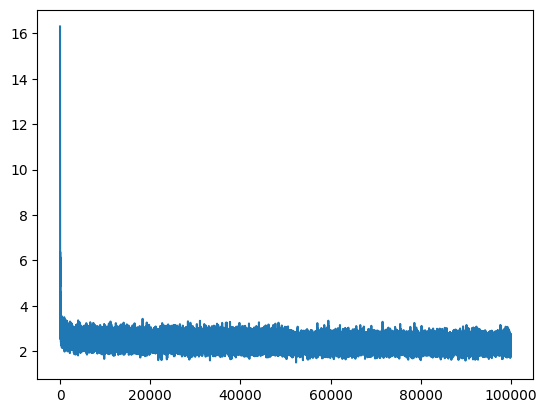

In [220]:
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

plt.plot(stepi, lossi)

In [221]:
logits = forward_pass(X_dev, params, False, 0)
ce = F.cross_entropy(logits, Y_dev)
ce.item()

2.2905352115631104

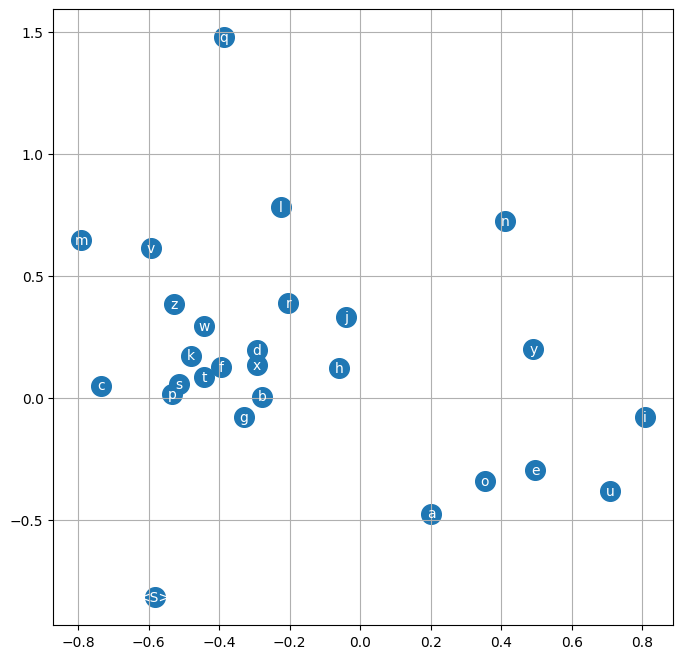

In [222]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), index_to_token[i], ha="center", va="center", color='white')
plt.grid('minor')

### Defining the model using PyTorch

In [92]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, vocab_size, emb_size, context_size, hidden_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.fc1 = nn.Linear(context_size * emb_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, vocab_size)
        
    def forward(self, x):
        emb = self.emb(x)                                    #(batch_size, context_size, emb_size)
        emb = emb.view(-1, context_size * emb_size)          #(batch_size, context_size * emb_size)
        h1 = torch.tanh(self.fc1(emb))                       #(batch_size, hidden_size)
        logits = self.fc2(h1)                                #(batch_size, vocab_size)
        return logits

model = MLP(vocab_size, emb_size, context_size, h_size)

In [95]:
sum(p.nelement() for p in model.parameters())

3481